# FPL Value Model - exploration

The pipeline now lives in `src/fpl_value_model/`. This notebook is the visual companion: it calls the package, checks the model on held-out seasons, backtests the value signal, and eyeballs the current under/over-priced lists.

Rebuild the caches first with `make data` (or pass `refresh=True`).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from fpl_value_model.backtest import walk_forward_backtest
from fpl_value_model.data import load_live_players, load_training_frame
from fpl_value_model.features import attach_history_features, build_feature_frame
from fpl_value_model.model import ValueModel, cross_validate_by_season

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## 1. Load data and build features

In [2]:
history = load_training_frame()
live = load_live_players()
features = build_feature_frame(history)
print('history rows      :', len(history))
print('training rows     :', len(features), '(minutes >= 450)')
print('seasons           :', sorted(features.season.unique()))
features.head()

history rows      : 2223
training rows     : 1608 (minutes >= 450)
seasons           : ['2022-23', '2023-24', '2024-25', '2025-26']


,player_id,name,season,position,team_id,price_m,goals_scored_per90,assists_per90,expected_goals_per90,expected_assists_per90,expected_goal_involvements_per90,ict_index_per90,bonus_per90,clean_sheets_per90,saves_per90,minutes
0,3,Granit Xhaka,2022-23,MID,1,4.8,0.210561,0.240642,0.139873,0.117012,0.256885,5.474599,0.451203,0.391043,0.0,2992
1,5,Rob Holding,2022-23,DEF,1,4.2,0.160142,0.000000,0.051246,0.024021,0.075267,3.459075,0.000000,0.000000,0.0,562
2,6,Thomas Partey,2022-23,MID,1,4.7,0.108871,0.000000,0.093992,0.078750,0.172742,4.336694,0.217742,0.399194,0.0,2480
3,7,Martin Ødegaard,2022-23,MID,1,6.9,0.431034,0.229885,0.280172,0.230460,0.510632,8.571839,0.862069,0.373563,0.0,3132
4,8,Kieran Tierney,2022-23,DEF,1,4.6,0.000000,0.116279,0.044186,0.050000,0.094186,3.476744,0.000000,0.116279,0.0,774


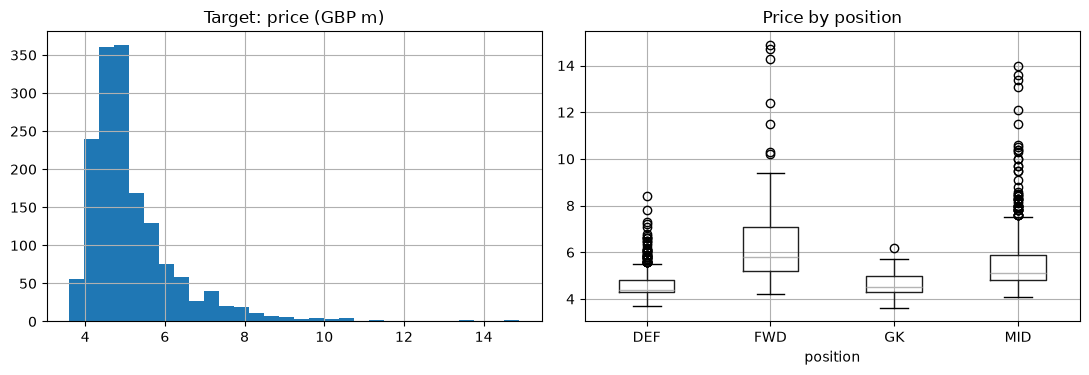

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
features['price_m'].hist(bins=30, ax=ax[0])
ax[0].set_title('Target: price (GBP m)')
features.boxplot(column='price_m', by='position', ax=ax[1])
ax[1].set_title('Price by position')
plt.suptitle(''); plt.tight_layout()

## 2. Season-held-out cross-validation

Each fold is scored on a season the model never trained on. The mean-price baseline is the bar to clear.

In [4]:
cross_validate_by_season(features).round(3)

,mae_m,r2
estimator,,
gbr,0.542,0.551
ridge,0.564,0.534
linear,0.564,0.534
baseline_mean,0.831,-0.003


## 3. Predicted vs actual price (linear model)

Refit on every season, then look at the fit and the residuals. Points far above the diagonal are players the model prices higher than the market: its underpriced picks.

Text(0.5, 1.0, 'Linear model: predicted vs actual')

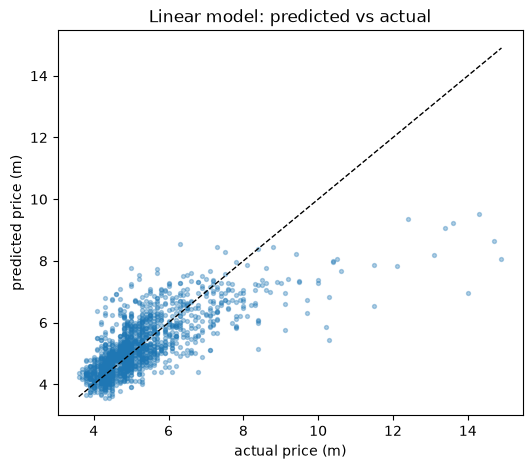

In [5]:
model = ValueModel().fit(features)
scored = model.score_frame(features)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(scored['price_m'], scored['pred_m'], s=8, alpha=0.35)
lims = [scored['price_m'].min(), scored['price_m'].max()]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('actual price (m)'); ax.set_ylabel('predicted price (m)')
ax.set_title('Linear model: predicted vs actual')

In [6]:
cols = ['name', 'season', 'position', 'price_m', 'pred_m', 'value_m']
print('Most underpriced (historical seasons):')
display(scored.head(10)[cols].round(2))
print('Most overpriced (historical seasons):')
display(scored.tail(10)[cols].round(2))

Most underpriced (historical seasons):


,name,season,position,price_m,pred_m,value_m
0,Deniz Undav,2022-23,FWD,5.0,7.78,2.78
1,Rodrigo Muniz Carvalho,2023-24,FWD,4.3,6.81,2.51
2,Chris Wood,2023-24,FWD,4.7,7.09,2.39
3,Taiwo Awoniyi,2025-26,FWD,5.2,7.56,2.36
4,Evan Ferguson,2022-23,FWD,4.6,6.92,2.32
5,Julio Enciso,2022-23,FWD,4.6,6.92,2.32
6,Alejandro Garnacho,2022-23,MID,4.1,6.38,2.28
7,Pablo Sarabia,2023-24,MID,4.5,6.77,2.27
8,Lukas Nmecha,2025-26,FWD,5.0,7.24,2.24
9,Cole Palmer,2023-24,MID,6.3,8.53,2.23


Most overpriced (historical seasons):


,name,season,position,price_m,pred_m,value_m
1598,Mohamed Salah,2023-24,MID,13.4,9.07,-4.33
1599,Cristiano Ronaldo dos Santos Aveiro,2022-23,FWD,10.2,5.86,-4.34
1600,Mohamed Salah,2024-25,MID,13.6,9.22,-4.38
1601,Erling Haaland,2023-24,FWD,14.3,9.53,-4.77
1602,Alexander Isak,2025-26,FWD,10.3,5.43,-4.87
1603,Mohamed Salah,2022-23,MID,13.1,8.18,-4.92
1604,Son Heung-min,2022-23,MID,11.5,6.53,-4.97
1605,Erling Haaland,2025-26,FWD,14.7,8.65,-6.05
1606,Erling Haaland,2024-25,FWD,14.9,8.06,-6.84
1607,Mohamed Salah,2025-26,MID,14.0,6.97,-7.03


## 4. Does the value signal pick better squads?

Walk-forward: fit on earlier seasons, draft the top 20 of each ranking from the prior season, and score them on the *next* season's points per million of acquisition cost. Higher is better.

In [7]:
walk_forward_backtest(history, top_n=20).round(2)

,2023-24,2024-25,2025-26,mean
model_value,17.15,21.75,18.41,19.11
fpl_form,18.63,18.27,19.76,18.89
points_per90,16.16,17.48,11.39,15.01
cheapest,12.58,11.05,15.88,13.17


## 5. Current player pool

Live players scored with their most recent season's per-90 form. Players with no history (new signings, academy) are dropped.

In [8]:
live_scored = model.score_frame(attach_history_features(live, history))
live_cols = ['name', 'position', 'price_m', 'pred_m', 'value_m', 'total_points', 'status']
print(f'{len(live_scored)} of {len(live)} live players had usable history')

unavailable = ~live_scored['available']
print(f'{unavailable.sum()} of those are currently injured, suspended, or unregistered (status != "a")')

available_scored = live_scored[~unavailable]
print('\nModel thinks these are underpriced (available players only):')
display(available_scored.head(15)[live_cols].round(2))
print('Model thinks these are overpriced (available players only):')
display(available_scored.tail(15)[live_cols].round(2))

print('\nUnavailable players that would otherwise rank in the top 15 underpriced (buyer beware):')
display(live_scored[unavailable].sort_values('value_m', ascending=False).head(15)[live_cols].round(2))

378 of 659 live players had usable history
105 of those are currently injured, suspended, or unregistered (status != "a")

Model thinks these are underpriced (available players only):


,name,position,price_m,pred_m,value_m,total_points,status
0,David Brooks,MID,5.0,6.98,1.98,2,a
1,Lukas Nmecha,FWD,5.4,7.25,1.85,6,a
3,Maxim De Cuyper,DEF,4.9,6.23,1.33,32,a
5,Wilson Isidor,FWD,5.5,6.72,1.22,14,a
6,Thierno Barry,FWD,5.6,6.81,1.21,14,a
9,Leif Davis,DEF,4.0,5.16,1.16,23,a
10,Jayden Bogle,DEF,4.5,5.66,1.16,37,a
11,Dominic Calvert-Lewin,FWD,6.0,7.13,1.13,20,a
13,Callum Wilson,FWD,5.5,6.55,1.05,3,a
14,Danny Welbeck,FWD,5.9,6.85,0.95,2,a


Model thinks these are overpriced (available players only):


,name,position,price_m,pred_m,value_m,total_points,status
362,Florian Wirtz,MID,7.4,6.20,-1.20,12,a
363,James Tarkowski,DEF,6.1,4.90,-1.20,29,a
365,Jarrad Branthwaite,DEF,5.5,4.12,-1.38,19,a
366,Maxence Lacroix,DEF,6.0,4.58,-1.42,10,a
367,Morgan Rogers,MID,7.7,6.28,-1.42,27,a
368,Declan Rice,MID,7.4,5.93,-1.47,19,a
369,Bukayo Saka,MID,9.5,7.85,-1.65,30,a
370,Virgil van Dijk,DEF,6.5,4.79,-1.71,17,a
371,Matheus Santos Carneiro da Cunha,MID,7.9,5.90,-2.00,16,a
372,Antoine Semenyo,MID,8.4,6.04,-2.36,16,a



Unavailable players that would otherwise rank in the top 15 underpriced (buyer beware):


,name,position,price_m,pred_m,value_m,total_points,status
2,Taiwo Awoniyi,FWD,5.5,6.95,1.45,3,s
4,Eddie Nketiah,FWD,5.5,6.78,1.28,7,d
7,Harvey Elliott,MID,5.4,6.58,1.18,0,u
8,Norberto Bercique Gomes Betuncal,FWD,5.4,6.57,1.17,2,u
12,Jack Hinshelwood,MID,5.9,7.02,1.12,16,i
17,Chiedozie Ogbene,MID,4.9,5.75,0.85,0,u
18,Jean-Philippe Mateta,FWD,6.3,7.15,0.85,2,i
19,Mykhailo Mudryk,MID,5.4,6.24,0.84,1,i
21,Ryan Sessegnon,DEF,4.4,5.20,0.80,3,d
22,Amine Adli,MID,4.9,5.68,0.78,0,i


## Notes

- Linear and ridge sit on top of each other; GBR is marginally ahead on MAE. Keep linear as the default for interpretability.
- Premium players (Haaland, Salah, Bruno) always read as 'overpriced': a linear model on per-90 counting stats can't see the captaincy / ownership / fixture-proof premium. Documented in `PROJECT.md`.
- The value signal beats raw FPL form only narrowly in the backtest.
- Done: live scoring now blends this-season form with last season's (weighted by minutes played so far), and carries FPL's `status`/`chance_of_playing_next_round` through as an `available` flag, so injured/suspended players don't silently top the underpriced list.
- Next ideas: team/fixture strength as a feature, position-specific models (GK/DEF value looks structurally different from MID/FWD), pricing the ~280 live players currently dropped for lacking PL history (new signings, promoted-team players), and predicting forward points directly instead of price -- the more direct fix for the premium-player residual.